<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UG04 — Data Analysis & Visualisation
**COMM061 NLP Coursework | Raaghav Kulshreshtha | 6776090**

## 1. Load Dataset

In [1]:
# Install required libraries
!pip install datasets

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [3]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [4]:
df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test = pd.DataFrame(ds['test'])

print(df_train.head())
print(df_train.columns.tolist())

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  
['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


## 2. Dataset Statistics

In [5]:
print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)

print("\nVariety counts (train):")
print(df_train['variety'].value_counts())

print("\nSource counts (train):")
print(df_train['source'].value_counts())

Training set shape: (3747, 5)
Validation set shape: (313, 5)
Test set shape: (2183, 5)

Variety counts (train):
variety
en-IN    1399
en-UK    1203
en-AU    1145
Name: count, dtype: int64

Source counts (train):
source
Google    1874
Reddit    1873
Name: count, dtype: int64


## 3. Label Distribution Visualisation (Q1.1)

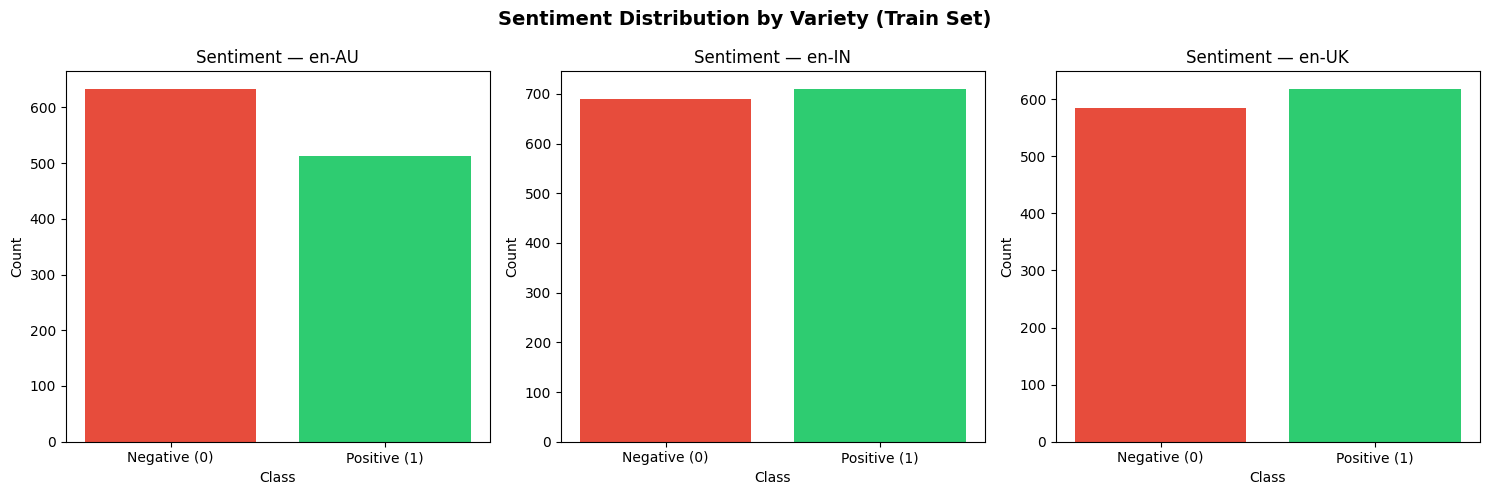

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

varieties = ['en-AU', 'en-IN', 'en-UK']
for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sentiment'].value_counts().sort_index()
    axes[i].bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'Sentiment — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sentiment Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

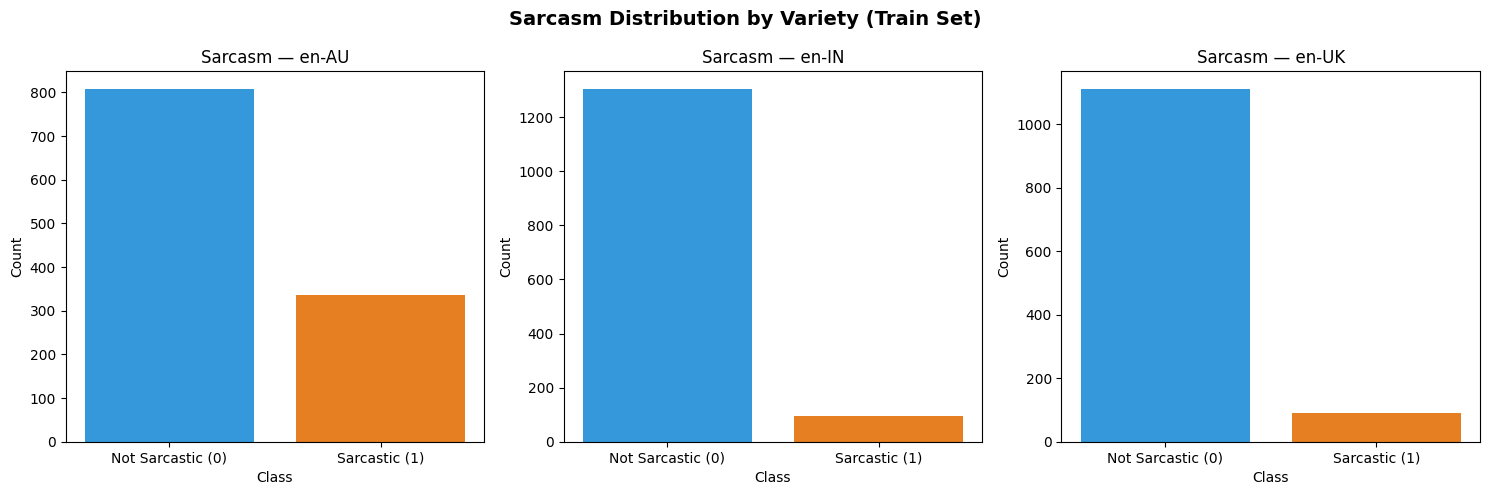

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sarcasm'].value_counts().sort_index()
    axes[i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Sarcasm — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sarcasm Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarcasm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

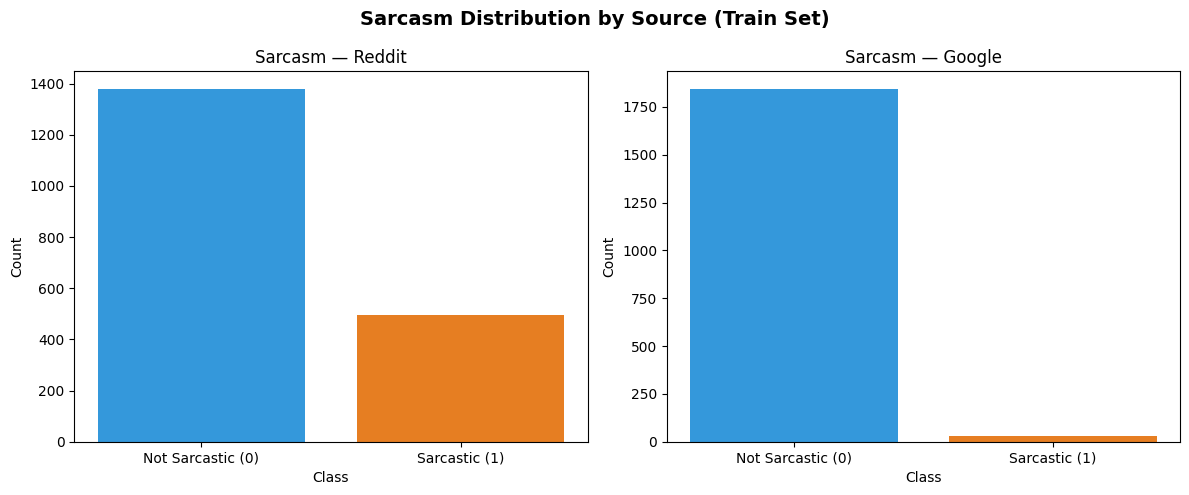

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sources = ['Reddit', 'Google']
for i, source in enumerate(sources):
    subset = df_train[df_train['source'] == source]
    counts = subset['Sarcasm'].value_counts().sort_index()
    axes[i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Sarcasm — {source}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sarcasm Distribution by Source (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarcasm_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Vocabulary Analysis (Q1.2)

In [9]:
df_au = df_train[df_train['variety'] == 'en-AU']
df_in = df_train[df_train['variety'] == 'en-IN']
df_uk = df_train[df_train['variety'] == 'en-UK']

print(f"en-AU: {len(df_au)} samples")
print(f"en-IN: {len(df_in)} samples")
print(f"en-UK: {len(df_uk)} samples")

en-AU: 1145 samples
en-IN: 1399 samples
en-UK: 1203 samples


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def get_vocabulary(df):
    vectorizer = CountVectorizer(stop_words='english', lowercase=True)
    vectorizer.fit(df['text'])
    return set(vectorizer.vocabulary_.keys())

vocab_au = get_vocabulary(df_au)
vocab_in = get_vocabulary(df_in)
vocab_uk = get_vocabulary(df_uk)

print(f"en-AU vocabulary size: {len(vocab_au)}")
print(f"en-IN vocabulary size: {len(vocab_in)}")
print(f"en-UK vocabulary size: {len(vocab_uk)}")

en-AU vocabulary size: 7789
en-IN vocabulary size: 7008
en-UK vocabulary size: 7157


Calculating Jaccard Similarity

In [11]:
def jaccard_similarity(vocab1, vocab2):
    intersection = len(vocab1 & vocab2)
    union = len(vocab1 | vocab2)
    return intersection / union

# Calculate Jaccard similarity between en-IN and the two inner-circle varieties
jaccard_in_au = jaccard_similarity(vocab_in, vocab_au)
jaccard_in_uk = jaccard_similarity(vocab_in, vocab_uk)
jaccard_au_uk = jaccard_similarity(vocab_au, vocab_uk)

print(f"Jaccard Similarity — en-IN vs en-AU: {jaccard_in_au:.4f}")
print(f"Jaccard Similarity — en-IN vs en-UK: {jaccard_in_uk:.4f}")
print(f"Jaccard Similarity — en-AU vs en-UK: {jaccard_au_uk:.4f}")

Jaccard Similarity — en-IN vs en-AU: 0.2745
Jaccard Similarity — en-IN vs en-UK: 0.2792
Jaccard Similarity — en-AU vs en-UK: 0.3345


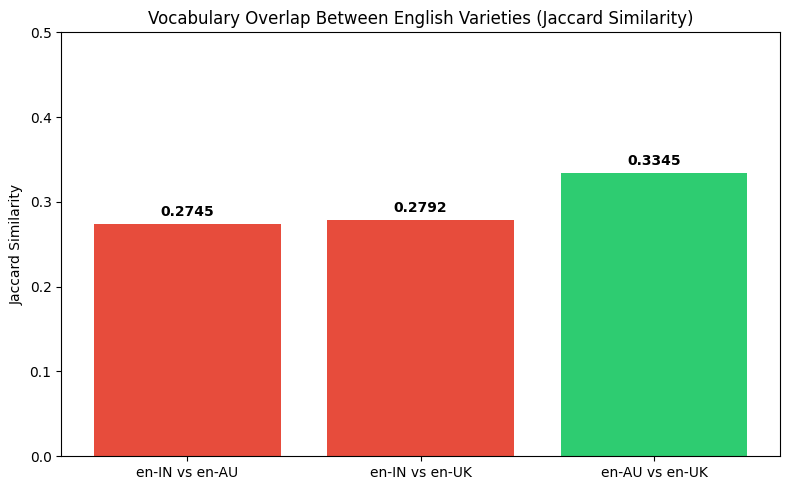

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

pairs = ['en-IN vs en-AU', 'en-IN vs en-UK', 'en-AU vs en-UK']
scores = [jaccard_in_au, jaccard_in_uk, jaccard_au_uk]
colors = ['#e74c3c', '#e74c3c', '#2ecc71']

bars = ax.bar(pairs, scores, color=colors)
ax.set_ylabel('Jaccard Similarity')
ax.set_title('Vocabulary Overlap Between English Varieties (Jaccard Similarity)')
ax.set_ylim(0, 0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('jaccard_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

### Linguistic Distance

Linguistic distance is basically how different two language varieties are from each other,
this includes differences in vocabulary, grammar, syntax and how language is used culturally.
For NLP models this matters because the bigger the gap between what a model was trained on
and what it's tested on, the worse it tends to perform. It might see words it's never encountered,
different sentence structures, or culturally specific phrases it has no context for.

Looking at the Jaccard scores, there's a pretty clear pattern. en-AU and en-UK have the highest
overlap at **0.3345**, which makes sense since they're both inner-circle varieties with similar
cultural contexts. en-IN scores noticeably lower against both, sitting at **0.2745** against en-AU
and **0.2792** against en-UK. That gap suggests there is some linguistic distance between Indian
English and the other two varieties.

That said, it's worth questioning how deep that distance actually is. A lot of the vocabulary
unique to en-IN seems to come from topic-specific terms rather than grammatical differences.
Things like "biryani", "momos", "chowkidar" appear in the Indian English subset and simply
don't show up elsewhere, which inflates the apparent distance. So part of this is probably
the dataset reflecting different cultural domains rather than fundamentally different grammar
or syntax. Even so, for a task like sarcasm detection where cultural context really matters,
even surface-level vocabulary differences could still affect how well a model transfers across
varieties.